In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append("../../src/")


import scipy.stats as stats
from tqdm import tqdm
from network_time_varying import TimeVaryingFeedForward

In [3]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'

In [4]:
net = TimeVaryingFeedForward(time_varying=True, n_days=100)
net.run()

setting seed: True
Inh scale timeline: [1.  1.  1.  1.  1.  1.  1.  0.7 0.7 0.7 0.7 0.7 0.7 0.7 1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1. ]


100%|██████████| 3000/3000 [01:08<00:00, 43.70it/s]


In [5]:
net_partial_mod = TimeVaryingFeedForward(time_varying=True, partial_modulation=True, n_days=100)
net_partial_mod.run()

setting seed: True
Scaling up modulation for subset of neurons to -2.220446049250313e-16 to achieve overall modulation of 0.7 with mod_frac of 0.3
Inh scale timeline: [ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00 -2.22044605e-16
 -2.22044605e-16 -2.22044605e-16 -2.22044605e-16 -2.22044605e-16
 -2.22044605e-16 -2.22044605e-16  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.0

100%|██████████| 3000/3000 [01:12<00:00, 41.23it/s]


In [6]:
# Characterise tuning curve with and without partial modulation

In [17]:
probe_angle = 100
cell_idx = 200

day = 9
exc_tuning_curve = net.estimate_tuning_curves_at_day(day)[cell_idx]
exc_tuning_curve_partial_mod = net_partial_mod.estimate_tuning_curves_at_day(day)[cell_idx]

In [8]:
exc_tuning_curve.shape

(100,)

Text(0.5, 1.0, 'Day 9 - Cell 200, probe angle 100°')

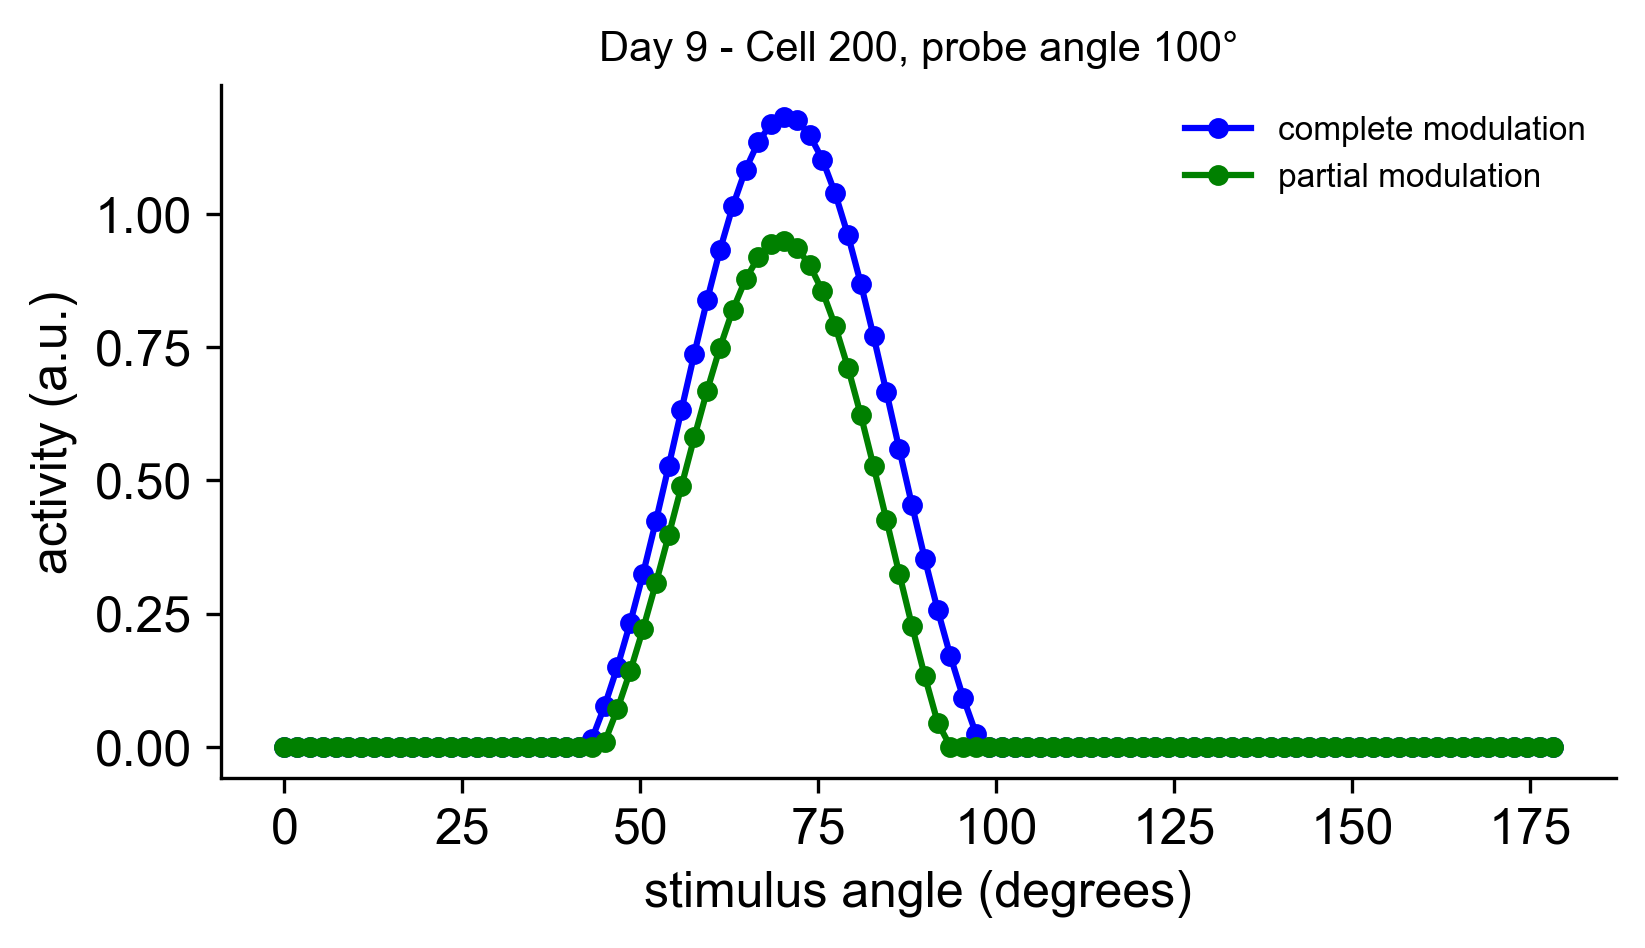

In [9]:
theta_list = np.linspace(0, 180, len(exc_tuning_curve), endpoint=False)
fig, axs = plt.subplots(1, 1, figsize=(6, 3), dpi=300)
axs.plot(theta_list, exc_tuning_curve, c='blue', marker='o', ms=4, label='complete modulation', clip_on=False)
axs.plot(theta_list, exc_tuning_curve_partial_mod, c='green', marker='o', ms=4, label='partial modulation', clip_on=False)
axs.set_xlabel('stimulus angle (degrees)')
axs.set_ylabel('activity (a.u.)')
axs.legend(frameon=False, fontsize=8)
axs.set_title(f"Day {day} - Cell {cell_idx}, probe angle {probe_angle}°", fontsize=10)

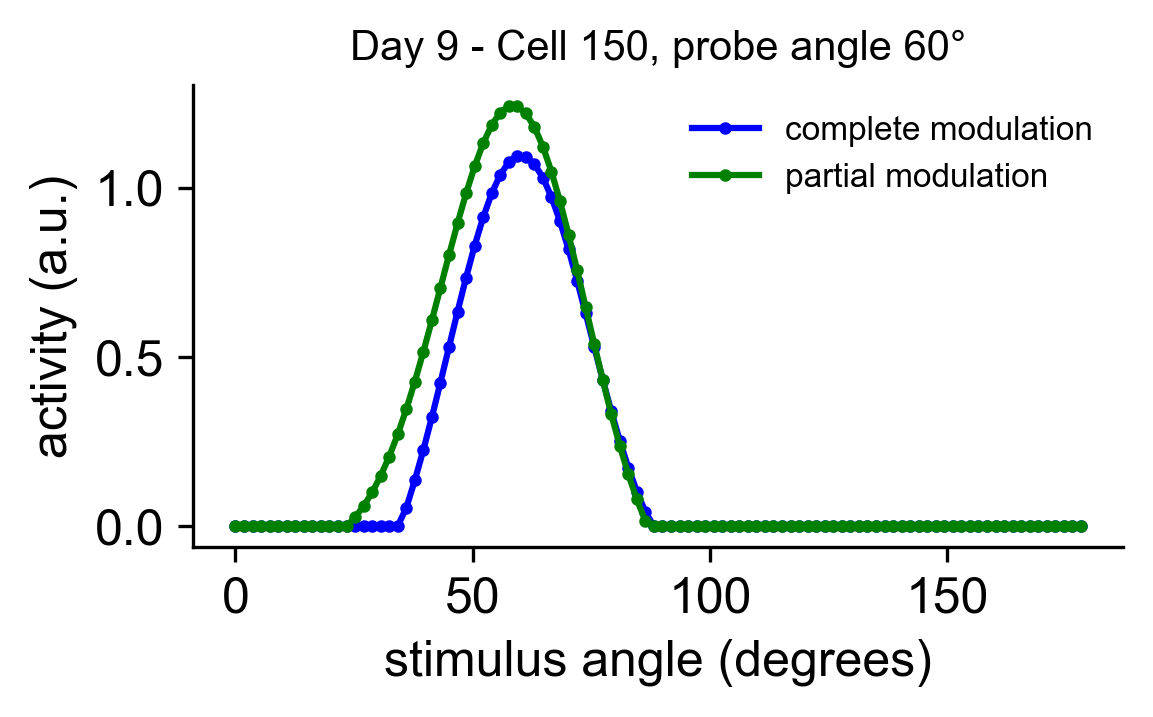

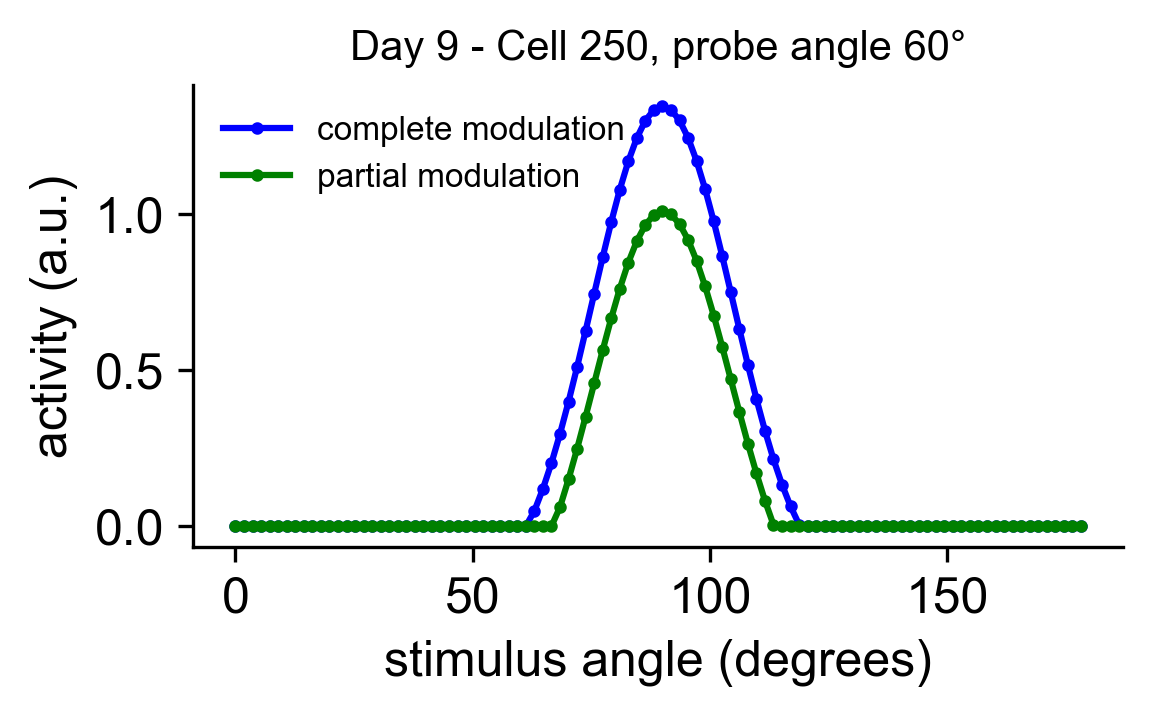

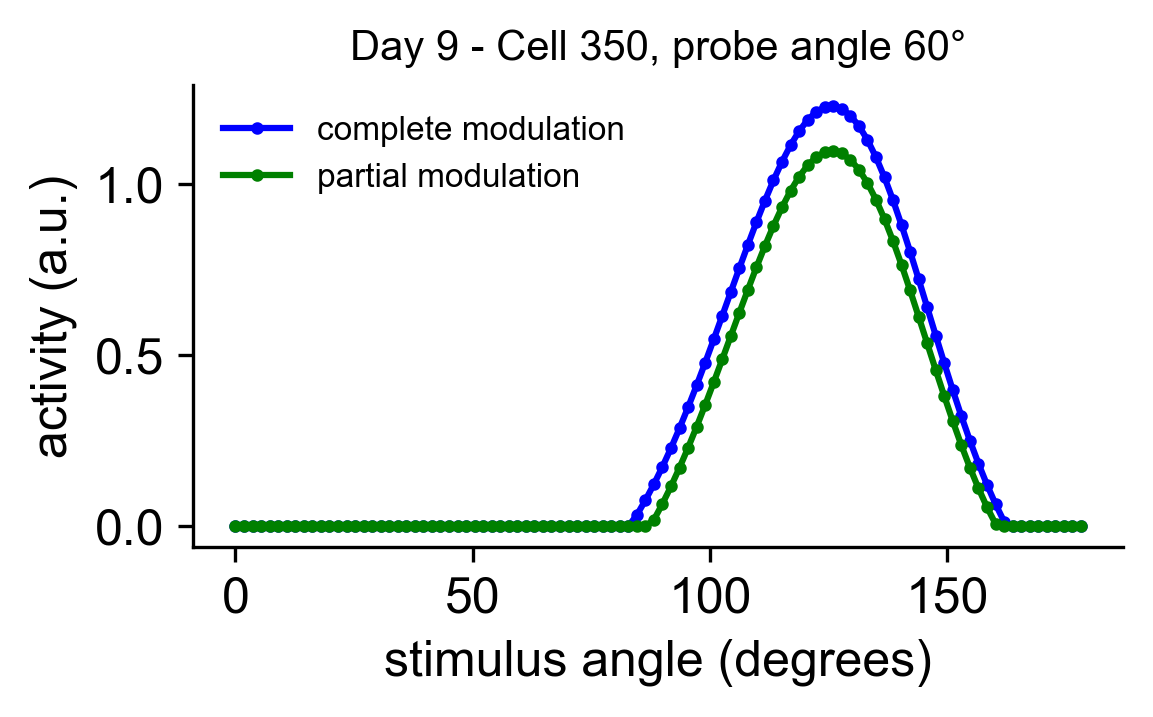

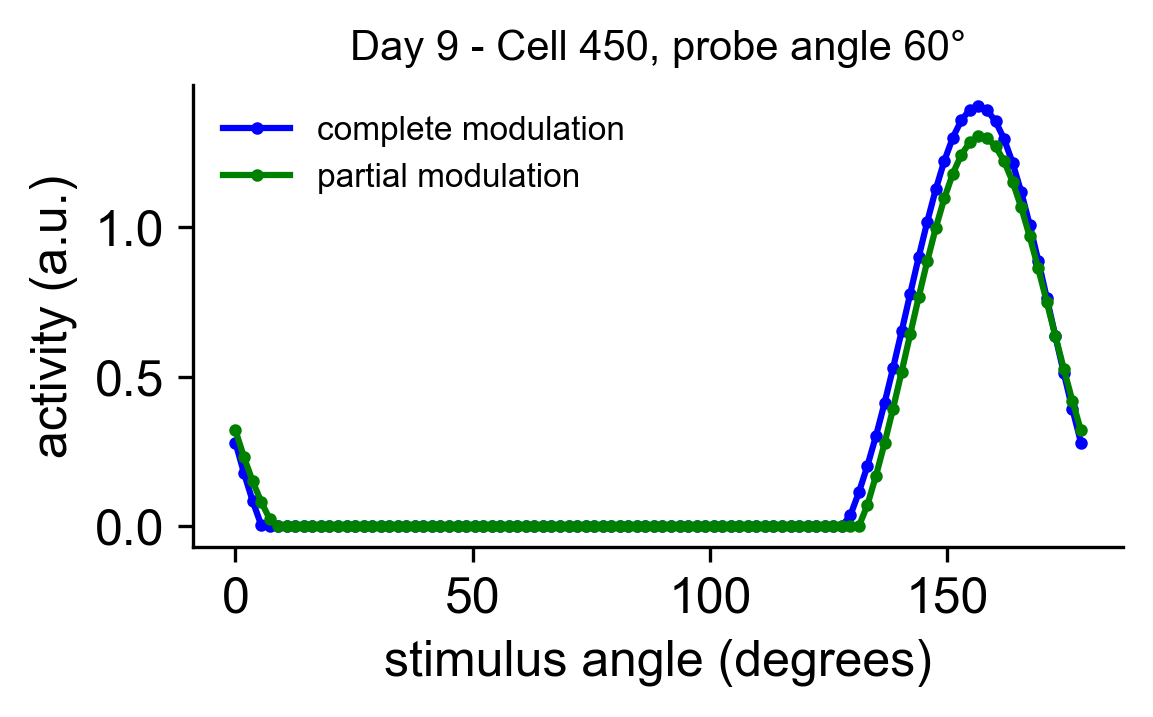

In [10]:
cell_idx_range = [150, 250, 350, 450]
day = 9
probe_angle = 60

theta_list = np.linspace(0, 180, len(exc_tuning_curve), endpoint=False)
for cell_idx in cell_idx_range:
    exc_tuning_curve = net.estimate_tuning_curves_at_day(day)[cell_idx]
    exc_tuning_curve_partial_mod = net_partial_mod.estimate_tuning_curves_at_day(day)[cell_idx]

    fig, axs = plt.subplots(1, 1, figsize=(4, 2), dpi=300)
    axs.plot(theta_list, exc_tuning_curve, c='blue', marker='o', ms=2, label='complete modulation', clip_on=False)
    axs.plot(theta_list, exc_tuning_curve_partial_mod, c='green', marker='o', ms=2, label='partial modulation', clip_on=False)
    axs.set_xlabel('stimulus angle (degrees)')
    axs.set_ylabel('activity (a.u.)')
    axs.legend(frameon=False, fontsize=8)
    axs.set_title(f"Day {day} - Cell {cell_idx}, probe angle {probe_angle}°", fontsize=10)

### Drift comparisons

In [11]:
drift_mag, drift_rate, convergence = net.get_metrics(net.N, net.n_days, net.theta_stim, net.POs)
drift_mag_partial_mod, drift_rate_partial_mod, convergence_partial_mod = net_partial_mod.get_metrics(net_partial_mod.N, net_partial_mod.n_days, net_partial_mod.theta_stim, net_partial_mod.POs)

In [18]:
drift_mag.shape

(100, 500)

<>:26: SyntaxWarning: invalid escape sequence '\;'
<>:26: SyntaxWarning: invalid escape sequence '\;'
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_23492/3525329041.py:26: SyntaxWarning: invalid escape sequence '\;'
  axs[2].set_ylabel('convergence $ \; [\degree]$')
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_23492/3525329041.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


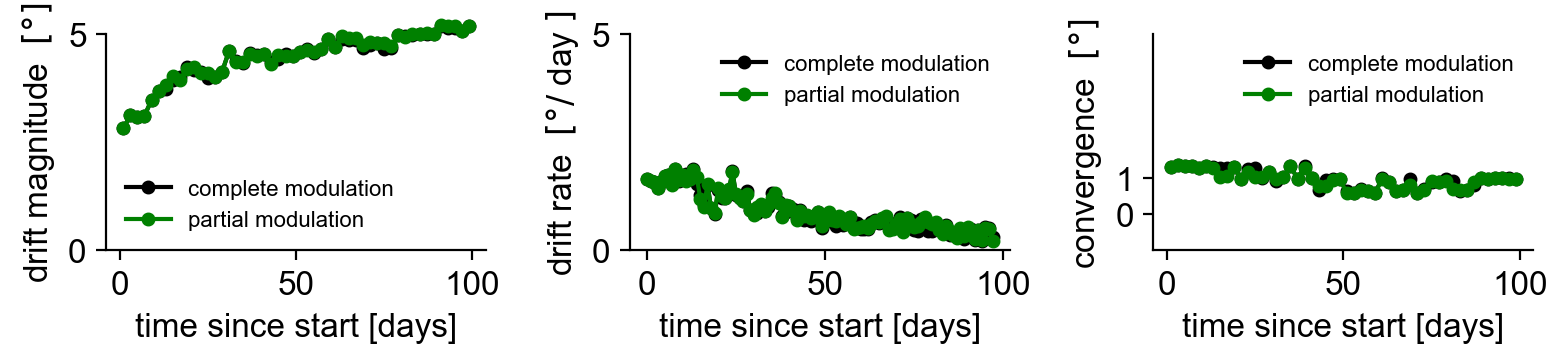

In [19]:
eo = 2


fig, axs = plt.subplots(1, 3, figsize=(8, 2), dpi=200)
axs[0].plot(np.arange(1, net.n_days)[::eo], np.median(drift_mag, axis=1)[:-1][::eo], c='black', ls='-', marker='o', ms=4, label='complete modulation', clip_on=False)
axs[0].plot(np.arange(1, net_partial_mod.n_days)[::eo], np.median(drift_mag_partial_mod, axis=1)[:-1][::eo], c='green', ls='-', marker='o', ms=4, label='partial modulation', clip_on=False)
axs[0].set_ylim([0, 5]); axs[0].set_yticks([0, 5])
axs[0].set_xlabel('time since start [days]')
axs[0].set_ylabel(r'drift magnitude $ \; [\degree]$')
# axs[0].set_xlim(0, 30)
axs[0].legend(frameon=False, fontsize=8)


axs[1].plot(np.mean(drift_rate, axis=1)[:-1], c='black', ls='-', marker='o', ms=4, label='complete modulation', clip_on=False)
axs[1].plot(np.mean(drift_rate_partial_mod, axis=1)[:-1], c='green', ls='-', marker='o', ms=4, label='partial modulation', clip_on=False)
axs[1].set_ylim([0, 5]); axs[1].set_yticks([0, 5])
axs[1].set_xlabel('time since start [days]')
axs[1].set_ylabel(r'drift rate $ \; [\degree / $ day $]$')
# axs[1].set_xlim(0, 30)  
axs[1].legend(frameon=False, fontsize=8)

axs[2].plot(np.arange(1, net.n_days)[::eo], np.median(convergence, axis=1)[::eo], c='black', ls='-', marker='o', ms=4, label='complete modulation', clip_on=False)
axs[2].plot(np.arange(1, net_partial_mod.n_days)[::eo], np.median(convergence_partial_mod, axis=1)[::eo], c='green', ls='-', marker='o', ms=4, label='partial modulation', clip_on=False)
axs[2].set_ylim([-1, 5]); axs[2].set_yticks([0, 1])
axs[2].set_xlabel('time since start [days]')
axs[2].set_ylabel('convergence $ \; [\degree]$')
# axs[2].set_xlim(0, 30)
axs[2].legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.show()

Text(0.5, 1.0, 'partial modulation')

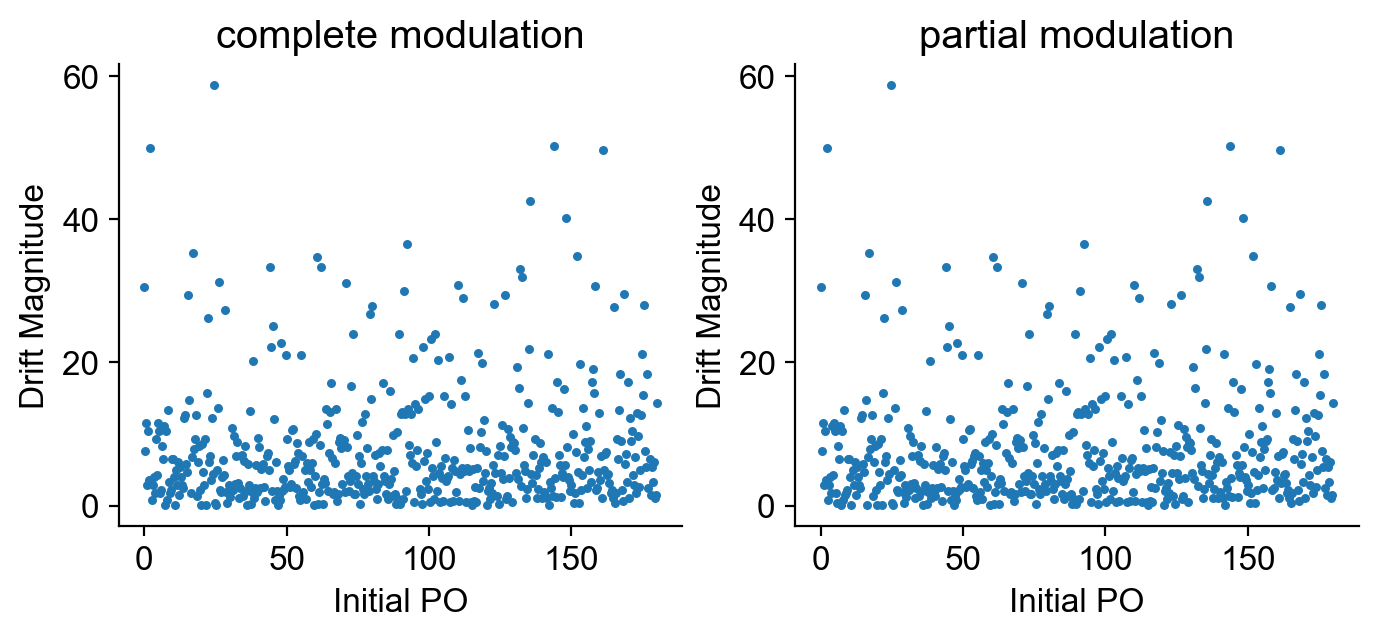

In [14]:
cell_pref_angles_init = np.linspace(0, 180, net.N)

fig, axs = plt.subplots(1, 2, figsize=(8, 3), dpi=200)

axs[0].scatter(cell_pref_angles_init, drift_mag[-1], s=5)
axs[0].set_xlabel('Initial PO')
axs[0].set_ylabel('Drift Magnitude')
axs[0].set_title('complete modulation')

axs[1].scatter(cell_pref_angles_init, drift_mag_partial_mod[-1], s=5)
axs[1].set_xlabel('Initial PO')
axs[1].set_ylabel('Drift Magnitude')
axs[1].set_title('partial modulation')

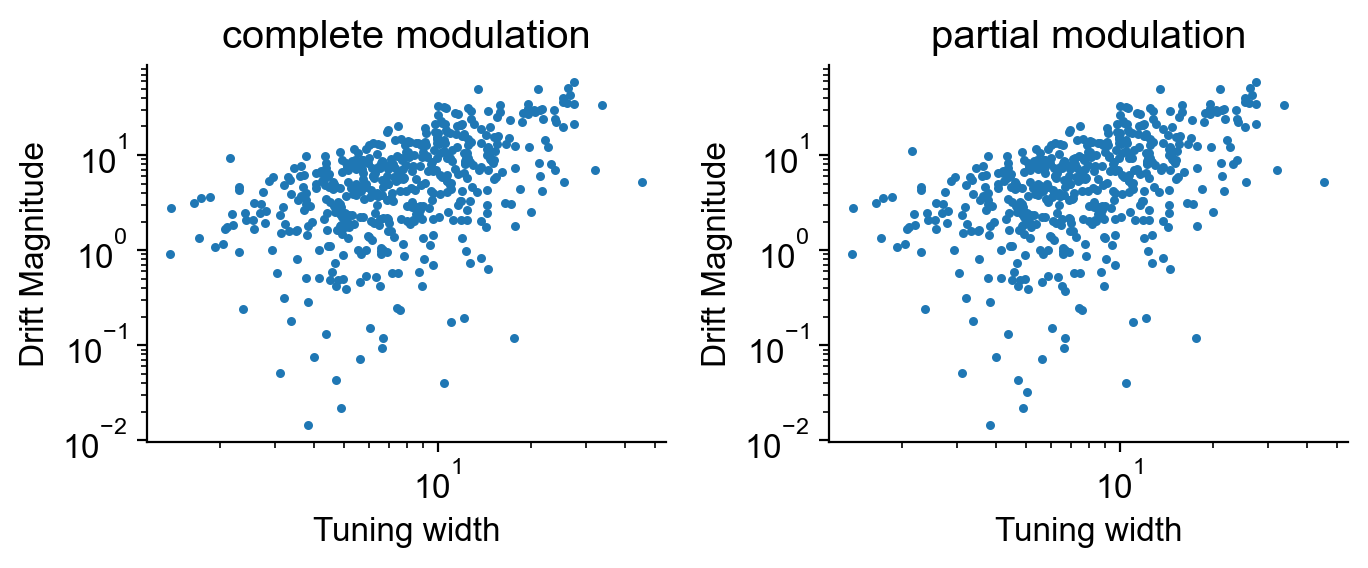

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(7, 3), dpi=200)

axs[0].scatter(net.vars_ef, drift_mag[-1], s=5)
axs[0].set_xlabel('Tuning width')
axs[0].set_ylabel('Drift Magnitude')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_title('complete modulation')

axs[1].scatter(net_partial_mod.vars_ef, drift_mag_partial_mod[-1], s=5)
axs[1].set_xlabel('Tuning width')
axs[1].set_ylabel('Drift Magnitude')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_title('partial modulation')

fig.tight_layout()

In [16]:
# Break down cells into n categories based on their initial PO
# plot drift magnitude, drift rate, and convergence for each category
